# Attention sequence-to-sequence translation

A from-scratch encoder, Bahdanau attention, and decoder translating human-written dates into ISO 8601 form. This demo trains on generated pairs and shows exact-match accuracy plus an attention-alignment heatmap. The full run in `scripts/train.py` reaches 100 percent exact match and BLEU 1.0.

In [1]:
from nmt import make_date_dataset, Seq2Seq, Trainer, greedy_decode, exact_match_accuracy, bleu, set_seed

set_seed(0)
data = make_date_dataset(n=6000, seed=0)
model = Seq2Seq(len(data.src_vocab), len(data.tgt_vocab),
                src_pad=data.src_vocab.pad_id, tgt_pad=data.tgt_vocab.pad_id)
trainer = Trainer(model, tgt_pad=data.tgt_vocab.pad_id, lr=1e-3)
trainer.fit(data, epochs=12, batch_size=128, verbose=False)
preds, _ = greedy_decode(model, data.sources[:300], data.src_vocab, data.tgt_vocab)
print('exact match:', round(exact_match_accuracy(preds, data.targets[:300]), 4))
print('BLEU:', round(bleu(preds, data.targets[:300]), 4))

exact match: 1.0
BLEU: 1.0


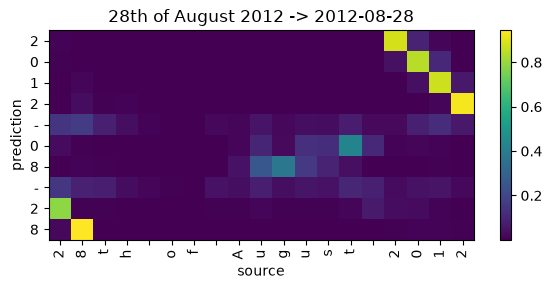

In [2]:
import matplotlib.pyplot as plt

example = ['28th of August 2012']
pred, attn = greedy_decode(model, example, data.src_vocab, data.tgt_vocab)
a = attn[0, :len(pred[0]), :len(example[0])].numpy()
plt.figure(figsize=(6, 3))
plt.imshow(a, aspect='auto', cmap='viridis')
plt.xticks(range(len(example[0])), list(example[0]), rotation=90)
plt.yticks(range(len(pred[0])), list(pred[0]))
plt.xlabel('source'); plt.ylabel('prediction'); plt.title(f'{example[0]} -> {pred[0]}')
plt.colorbar(); plt.tight_layout(); plt.show()